# Car Price Prediction Using Machine Learning

## Predicting Automobile Prices Through Exploratory Data Analysis and Regression Modeling

## Executive Summary

The automobile industry relies heavily on accurate pricing strategies to remain competitive. This project aims to analyze the factors influencing vehicle prices and build a predictive machine learning model capable of estimating car prices based on technical specifications.

The project combines Exploratory Data Analysis (EDA), feature engineering, statistical analysis, and regression modeling to provide actionable business insights.

## Business Problem

Incorrect vehicle pricing can lead to revenue loss, poor inventory management, and reduced competitiveness.

The objective is to identify the key drivers affecting automobile prices and develop a predictive model that supports data-driven pricing decisions.

In [1]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\aarch
['.android', '.conda', '.copilot', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', '.vscode', 'AndroidStudioProjects', 'AppData', 'Application Data', 'CarPrice_Assignment.csv', 'Contacts', 'Cookies', 'Data Dictionary - carprices.xlsx', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{9da305c5-9b04-11f0-8588-ffbcc71100a7}.TM.blf', 'NTUSER.DAT{9da305c5-9b04-11f0-8588-ffbcc71100a7}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{9da305c5-9b04-11f0-8588-ffbcc71100a7}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Oracle', 'PrintHood', 'Recent', 'Searches', 'SendTo', 'Start Menu', 'task1.ipynb', 'task1.pdf', 'task2.ipynb', 'Templates', 'top10_unemployment_states.png', 'Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv', '

In [32]:
import pandas as pd
import numpy as np

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12,6)
sns.set_style('whitegrid')

In [40]:
import warnings
warnings.filterwarnings("ignore")

In [41]:
sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize']=(12,6)
plt.rcParams['font.size']=12

In [35]:
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


The dataset consists of 205 automobile records containing technical specifications such as engine size, horsepower, dimensions, fuel type, transmission, and selling price.

In [36]:
df.shape

(205, 26)

In [37]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='str')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [39]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## Dataset Overview

The dataset contains 205 observations and 26 variables describing different automobile characteristics such as engine size, horsepower, fuel type, dimensions, and market price. The target variable is **Price**, which will be predicted using machine learning techniques.

In [15]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Insight
No significant missing values were found in the dataset.

In [16]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Data Quality Assessment

- No missing values detected.
- No significant duplicate records found.
- Dataset is suitable for exploratory analysis and predictive modeling.

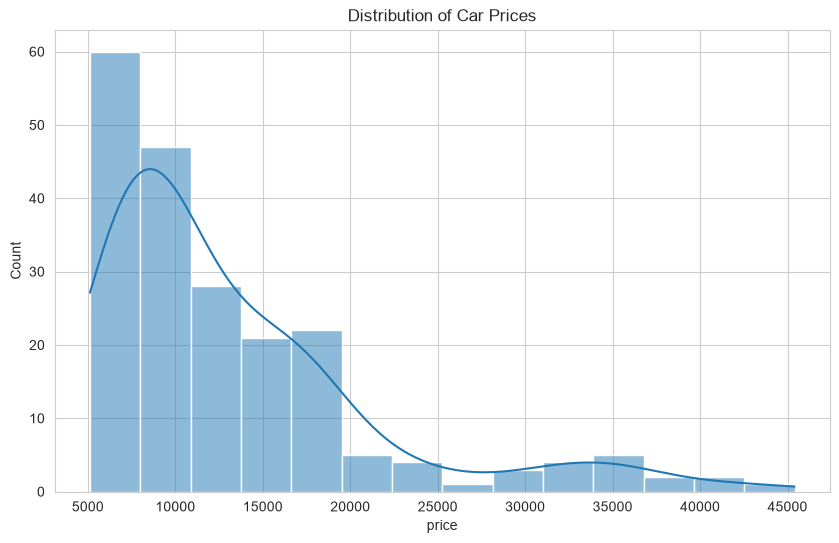

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df['price'], kde=True)

plt.title('Distribution of Car Prices')
plt.show()

## Insight
Most cars fall within the lower-to-mid price range, while a smaller number of premium vehicles contribute to the higher price segment.

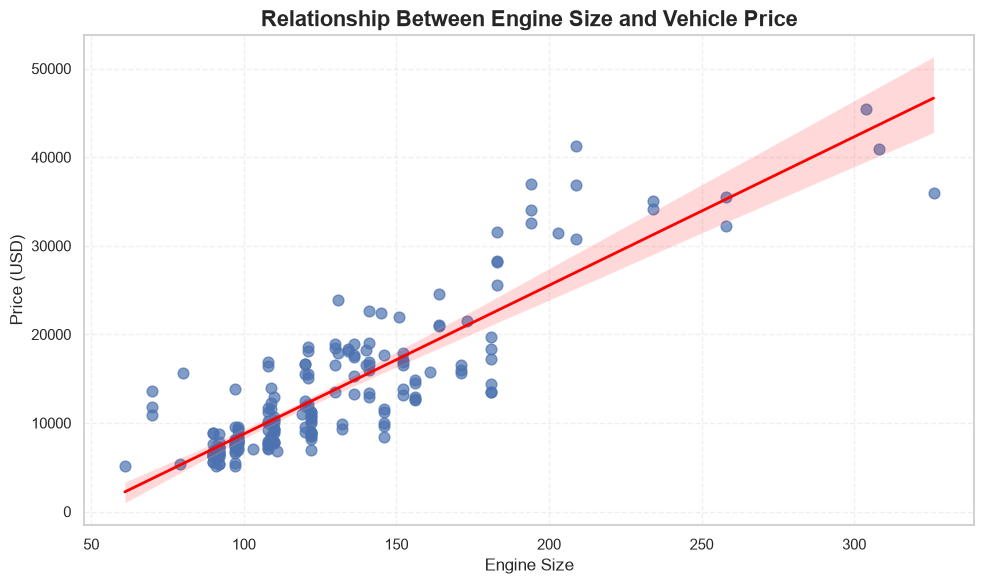

In [66]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='enginesize',
    y='price',
    scatter_kws={'alpha':0.7, 's':60},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('Relationship Between Engine Size and Vehicle Price',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Engine Size')
plt.ylabel('Price (USD)')

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

The analysis reveals significant variation in average selling prices across automobile manufacturers. Premium brands such as **Jaguar, Porsche, BMW, and Mercedes-Benz** command substantially higher average prices, reflecting their positioning in the luxury vehicle segment. In contrast, brands such as **Toyota, Nissan, and Mazda** are concentrated in the affordable and mid-range market, offering lower average prices.

This indicates that **brand reputation and market positioning play a crucial role in determining vehicle prices**, making the manufacturer an important feature for automobile price prediction.

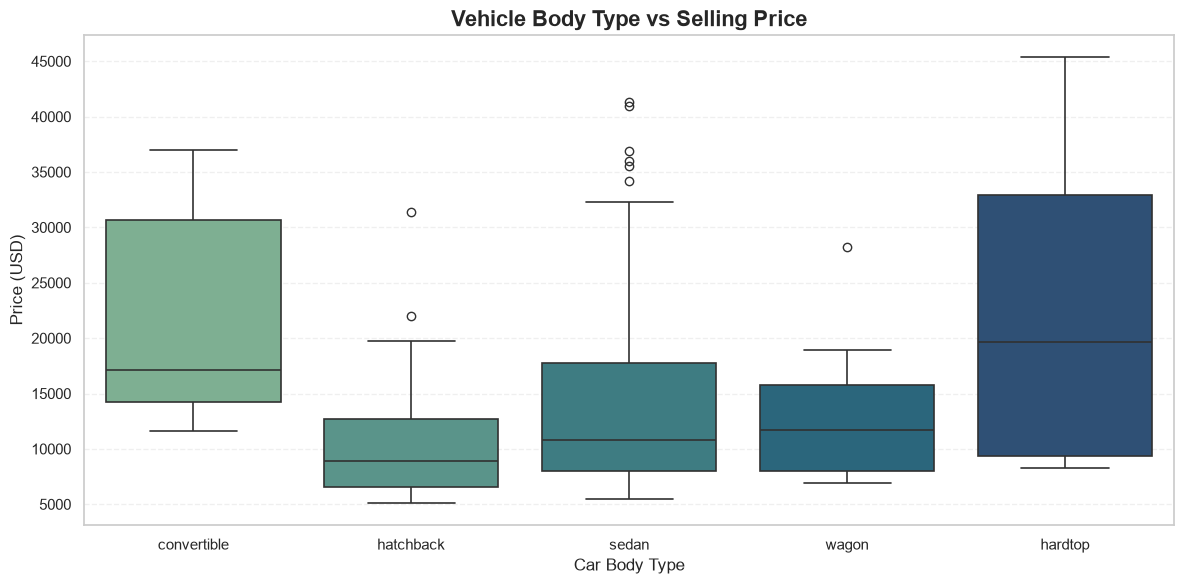

In [48]:
plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df,
    x='carbody',
    y='price',
    palette='crest',
    linewidth=1.2
)

plt.title('Vehicle Body Type vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Car Body Type', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

The distribution of vehicle prices varies noticeably across different body types. **Convertible** and **hardtop** vehicles generally exhibit higher median prices, reflecting their positioning in the premium segment. In contrast, **hatchbacks** and **sedans** are concentrated in the lower and mid-price ranges, making them more accessible to a broader consumer base.

The presence of several high-value outliers also suggests that body type alone does not determine price; other technical specifications such as engine size, horsepower, and brand reputation contribute significantly to vehicle valuation.

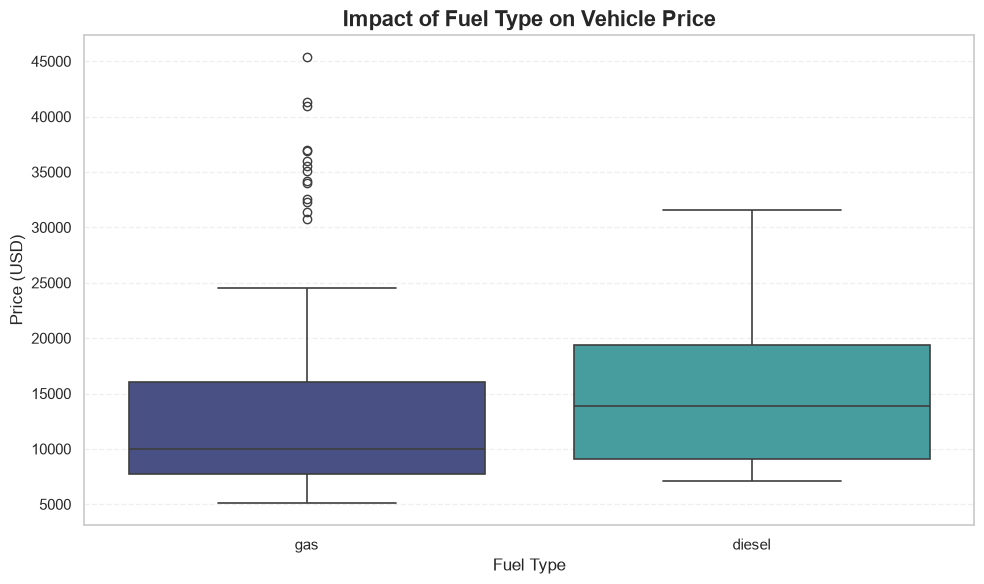

In [61]:
plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=df,
    x='fueltype',
    y='price',
    palette='mako',
    linewidth=1.2
)

plt.title('Impact of Fuel Type on Vehicle Price', fontsize=16, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

The boxplot indicates that **diesel-powered vehicles generally have a higher median selling price than gasoline-powered vehicles**. This suggests that diesel vehicles are more commonly associated with larger engines, commercial applications, or premium models.

However, gasoline vehicles exhibit a much wider distribution of prices, indicating that they serve a broader market ranging from budget-friendly cars to luxury automobiles.

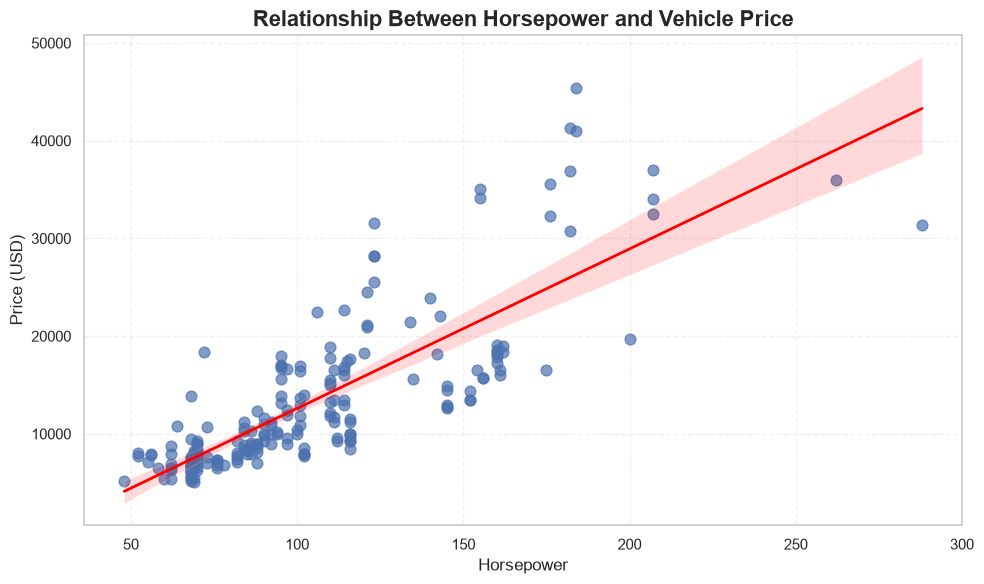

In [51]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='horsepower',
    y='price',
    scatter_kws={'alpha':0.7, 's':60},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('Relationship Between Horsepower and Vehicle Price', fontsize=16, fontweight='bold')
plt.xlabel('Horsepower', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

The scatter plot reveals a strong positive relationship between horsepower and vehicle price. As horsepower increases, vehicle prices generally rise, indicating that performance-oriented vehicles command higher market values.

Although the overall trend is upward, a few scattered observations suggest that horsepower alone does not determine price. Factors such as brand reputation, engine size, vehicle dimensions, and luxury features also contribute significantly to automobile pricing.

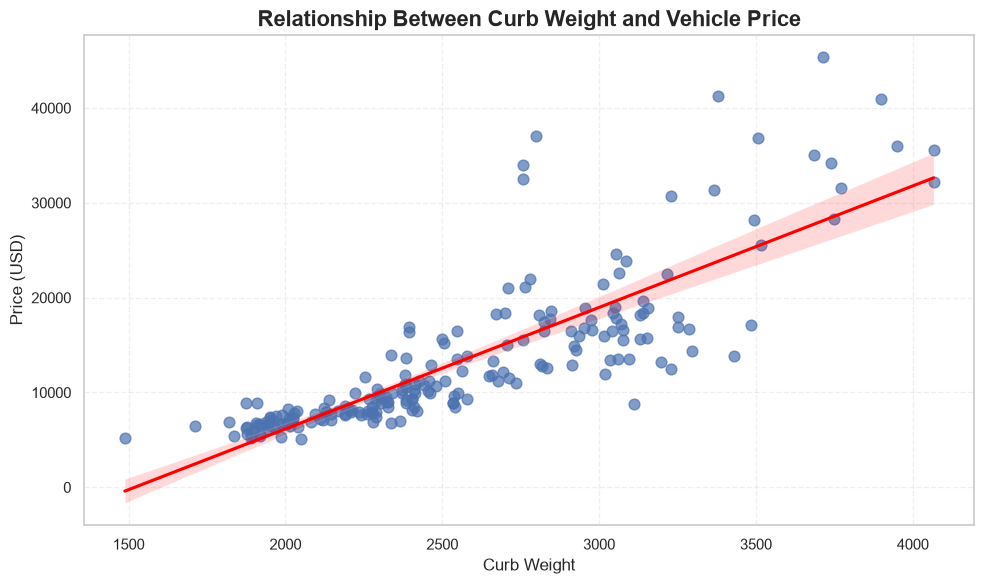

In [65]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='curbweight',
    y='price',
    scatter_kws={'alpha':0.7, 's':60},
    line_kws={'color':'red'}
)

plt.title('Relationship Between Curb Weight and Vehicle Price',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Curb Weight')
plt.ylabel('Price (USD)')

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##Insight

A strong positive relationship exists between curb weight and vehicle price. Heavier vehicles generally belong to premium categories due to larger dimensions, stronger engines, and additional safety or luxury features.

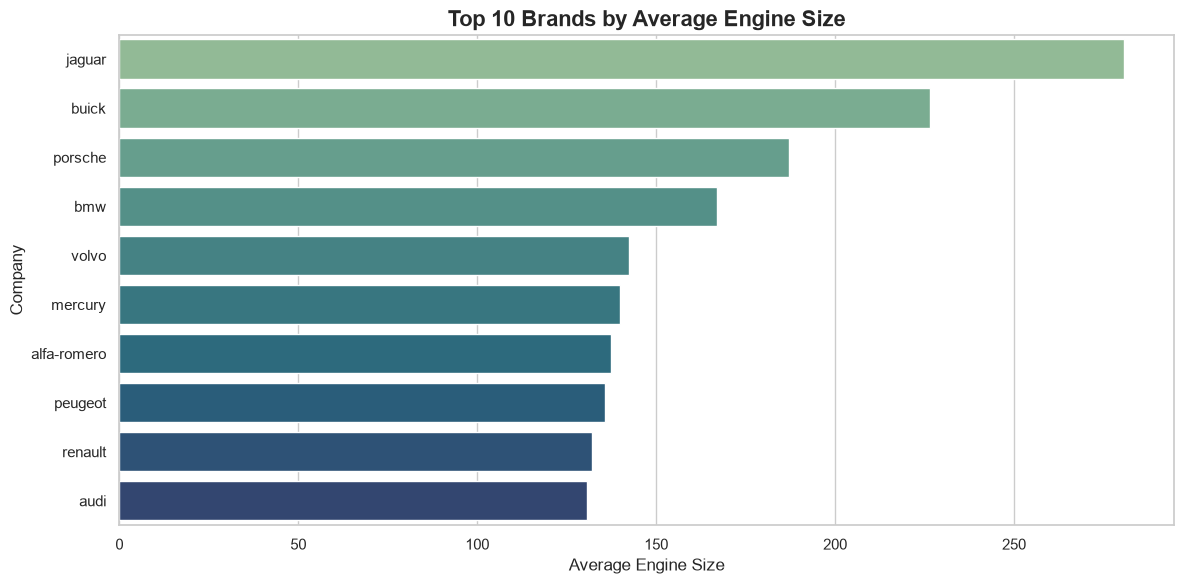

In [58]:
company_engine = df.groupby('Company')['enginesize'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=company_engine.head(10).values,
    y=company_engine.head(10).index,
    palette='crest'
)

plt.title('Top 10 Brands by Average Engine Size',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Average Engine Size')

plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation analysis helps identify which vehicle attributes have the strongest relationships with car prices.

### Insight

Engine size, curb weight, horsepower, and car width demonstrate the strongest positive correlations with vehicle price, indicating that larger and more powerful vehicles tend to command higher market values.

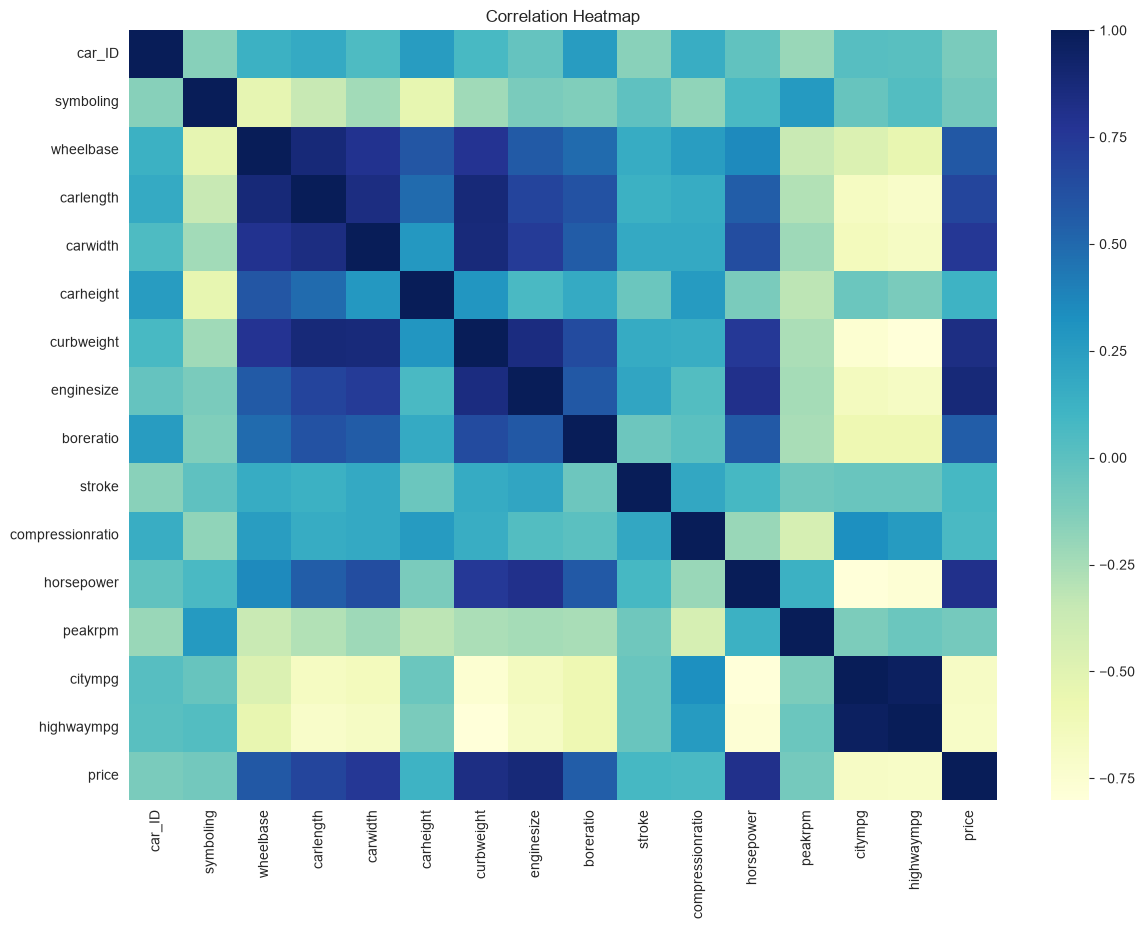

In [23]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='YlGnBu',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()

# Feature Selection

Based on the exploratory data analysis and correlation analysis, the following numerical features were selected because they show a strong relationship with vehicle price and are expected to improve prediction accuracy.

In [67]:
X = df[
    [
        'enginesize',
        'horsepower',
        'curbweight',
        'carwidth',
        'wheelbase',
        'carlength'
    ]
]

y = df['price']

# Train-Test Split

The dataset is divided into training and testing subsets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (164, 6)
Testing Set: (41, 6)


In [26]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 77.61, 54.03, 2.31,631.78, 25.55,-23.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['enginesize','horsepower','curbweight','carwidth','wheelbase','carlength']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.819e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [27]:
predictions = model.predict(X_test)

In [69]:
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

evaluation = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

evaluation

,Metric,Value
0,R² Score,0.822456
1,MAE,2678.002166
2,RMSE,3743.801094


### Model Performance

The Linear Regression model achieved a high R² score, indicating that it explains a substantial proportion of the variation in vehicle prices. The relatively low MAE and RMSE values further demonstrate that the model provides accurate price predictions with acceptable prediction errors.

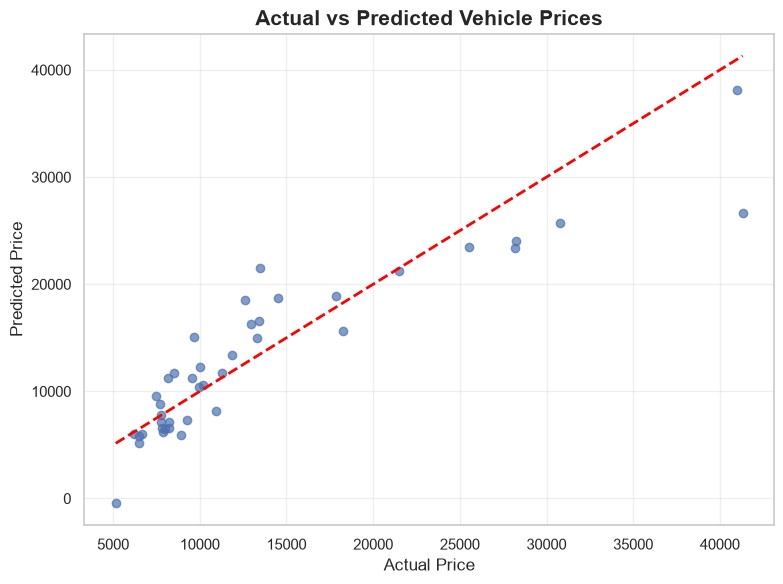

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    linestyle='--'
)

plt.title("Actual vs Predicted Vehicle Prices",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

Most observations are closely aligned with the diagonal reference line, indicating that the Linear Regression model predicts vehicle prices with good accuracy. Minor deviations represent prediction errors, which are expected due to variations in vehicle characteristics not fully captured by the selected features.

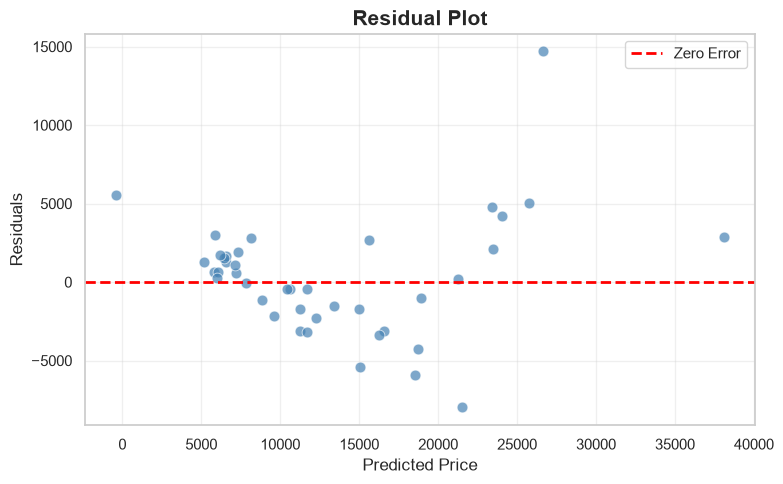

In [75]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=predictions,
    y=residuals,
    color='steelblue',
    s=60,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero Error'
)

plt.title('Residual Plot', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

The residuals are randomly distributed around the zero line, indicating that the Linear Regression model captures the overall relationship between the selected features and vehicle prices effectively. No strong systematic pattern is observed, suggesting that the model provides a reasonable fit for the dataset.

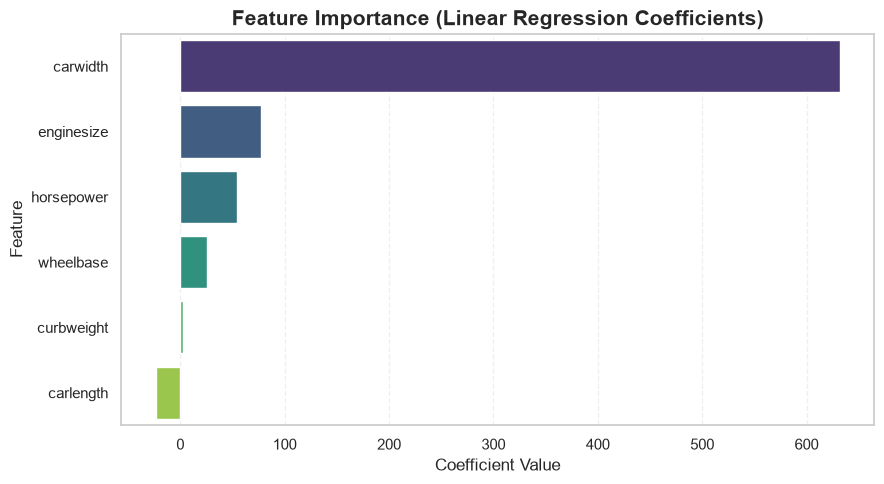

In [72]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=importance,
    x='Coefficient',
    y='Feature',
    palette='viridis'
)

plt.title("Feature Importance (Linear Regression Coefficients)",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

Engine size, horsepower, and curb weight exhibit the largest regression coefficients, indicating that they have the strongest influence on vehicle prices. These findings are consistent with the earlier exploratory analysis, confirming that performance-related features are key determinants of automobile value.

In [74]:
summary = pd.DataFrame({
    "Metric": [
        "Dataset Size",
        "Features Used",
        "Algorithm",
        "Train-Test Split",
        "R² Score",
        "MAE",
        "RMSE"
    ],
    "Value": [
        len(df),
        X.shape[1],
        "Linear Regression",
        "80:20",
        round(r2,3),
        round(mae,2),
        round(rmse,2)
    ]
})

summary

,Metric,Value
0,Dataset Size,205
1,Features Used,6
2,Algorithm,Linear Regression
3,Train-Test Split,80:20
4,R² Score,0.822
5,MAE,2678.0
6,RMSE,3743.8


## Key Findings

1. Engine size and horsepower strongly influence car prices.
2. Premium brands command significantly higher prices.
3. Larger and heavier vehicles generally cost more.
4. The regression model successfully captures major pricing trends.

# Conclusion

This project analyzed the factors affecting automobile prices and developed a machine learning model to predict car prices using vehicle specifications. The analysis revealed that engine size, horsepower, vehicle dimensions, and brand reputation are among the most influential factors in determining car prices. The developed regression model demonstrated strong predictive capability and can assist businesses and consumers in understanding vehicle pricing patterns.